<a href="https://colab.research.google.com/github/ElsaMolina/Cursos_EstadisticasConPython/blob/main/Optimizaci%C3%B3n_aeroporturaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [38]:
datos =pd.read_csv('/content/flights.csv')
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [5]:
datos.shape

(71175, 11)

In [8]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [11]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


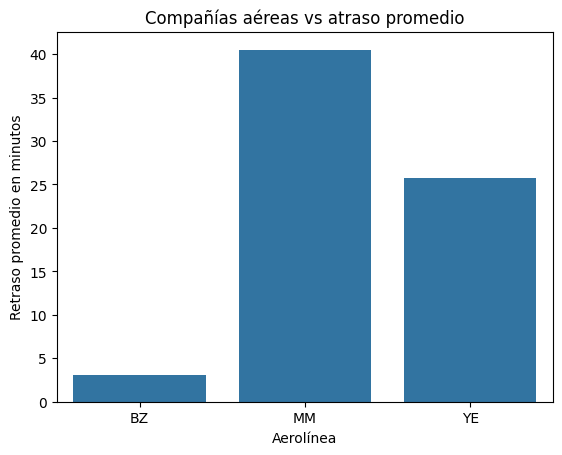

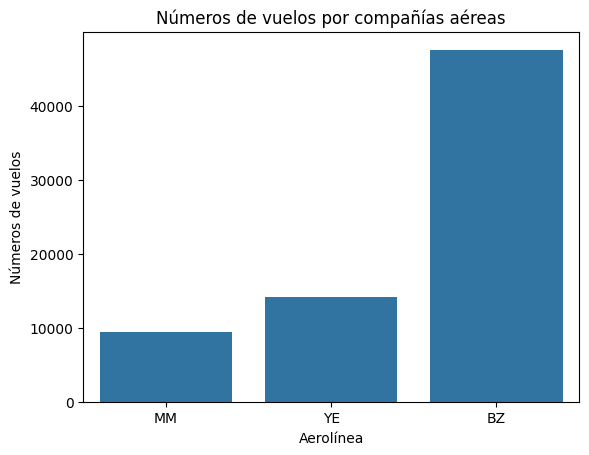

In [13]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y='delay', data=avg_delay)
plt.title ('Compañías aéreas vs atraso promedio')
plt.xlabel('Aerolínea')
plt.ylabel('Retraso promedio en minutos')
plt.show()

sns.countplot(x='airline', data=datos)
plt.title('Números de vuelos por compañías aéreas')
plt.xlabel('Aerolínea')
plt.ylabel('Números de vuelos')
plt.show()

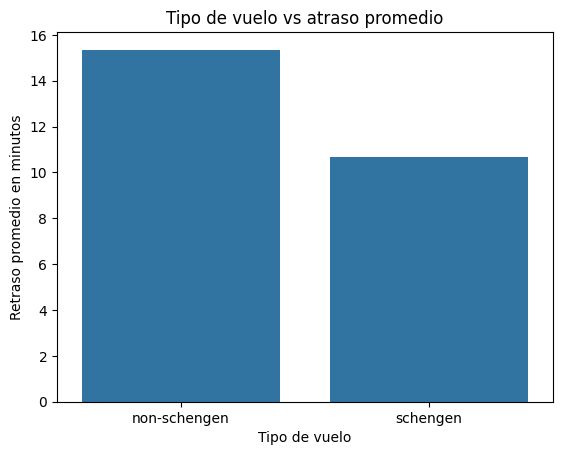

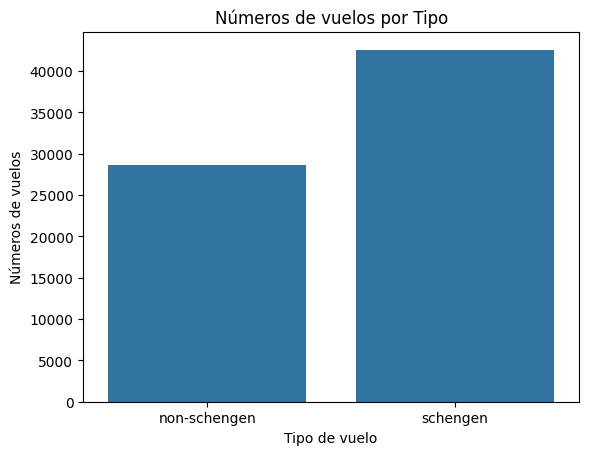

In [14]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y='delay', data=avg_delay)
plt.title ('Tipo de vuelo vs atraso promedio')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Retraso promedio en minutos')
plt.show()

sns.countplot(x='schengen', data=datos)
plt.title('Números de vuelos por Tipo')
plt.xlabel('Tipo de vuelo')
plt.ylabel('Números de vuelos')
plt.show()

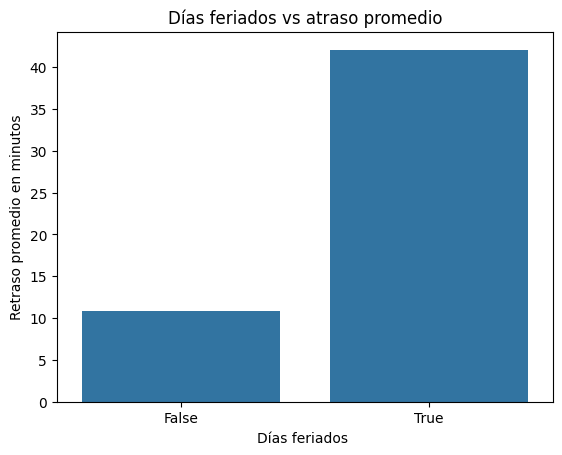

In [15]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y='delay', data=avg_delay)
plt.title ('Días feriados vs atraso promedio')
plt.xlabel('Días feriados ')
plt.ylabel('Retraso promedio en minutos')
plt.show()

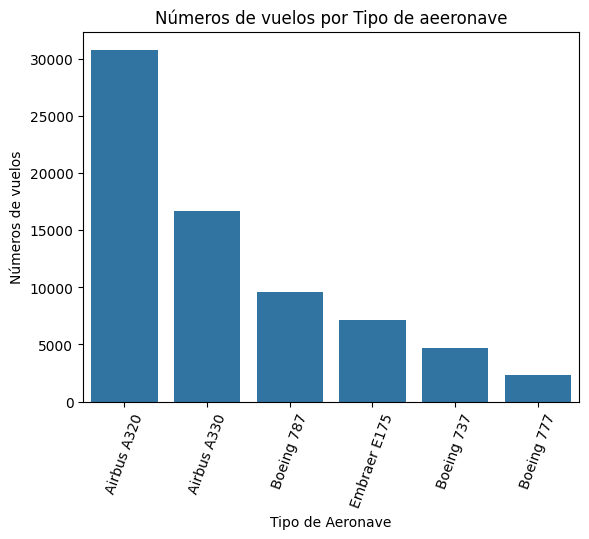

In [17]:
order =datos['aircraft_type'].value_counts().index
sns.countplot(x='aircraft_type', data=datos, order=order)
plt.title('Números de vuelos por Tipo de aeeronave')
plt.xticks(rotation=70)
plt.xlabel('Tipo de Aeronave')
plt.ylabel('Números de vuelos')
plt.show()

<Axes: xlabel='arrival_time', ylabel='Count'>

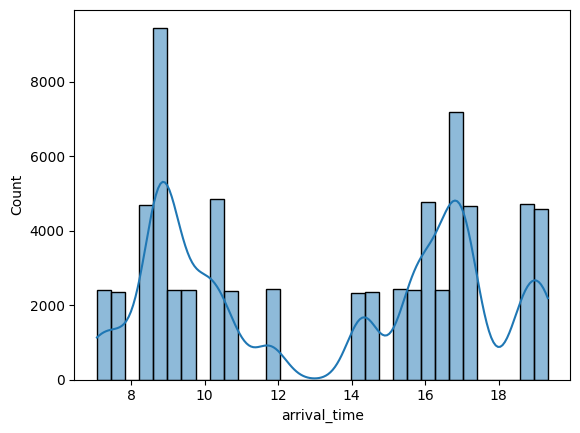

In [18]:
sns.histplot(data =datos, x='arrival_time', kde=True)

In [25]:
import numpy as np

def ancho_bin(df,columna):
  q75,q25 =np.percentile(df[columna],[75,25])
  iqr=q75-q25
  ancho=2*iqr * np.power(len(df[columna]), -1/3)
  return ancho

<Axes: xlabel='arrival_time', ylabel='Count'>

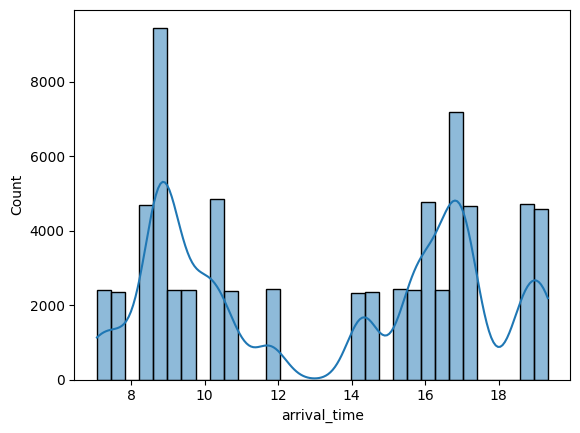

In [26]:
binwidth = ancho_bin(datos, 'arrival_time' )
sns.histplot(data=datos, x='arrival_time', kde= True, binwidth = binwidth)

<Axes: xlabel='departure_time', ylabel='Count'>

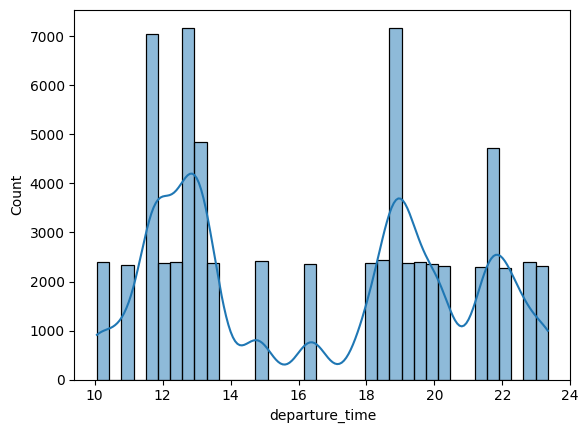

In [27]:
binwidth = ancho_bin(datos, 'departure_time' )
sns.histplot(data=datos, x='departure_time', kde= True, binwidth = binwidth)

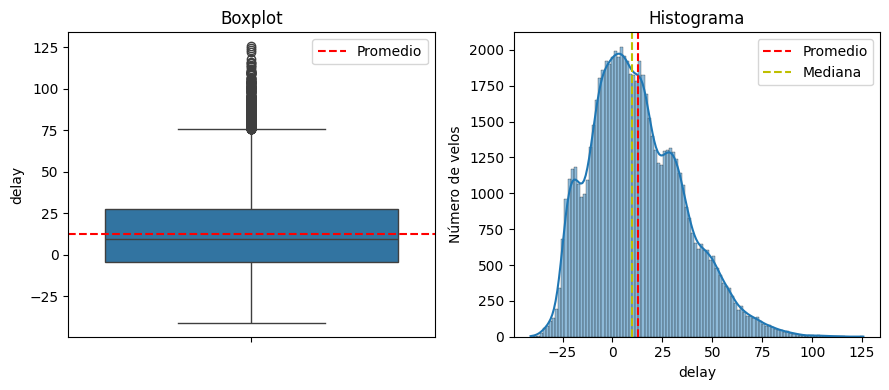

In [33]:
atraso_promedio = datos['delay'].mean()
atraso_mediana = datos['delay'].median()

fig,ax= plt.subplots(1,2, figsize=(94))

sns.boxplot(data=datos, y='delay', ax=ax[0])
ax[0].set_title('Boxplot')
ax[0].axhline(y=atraso_promedio, color='r', linestyle='--', label='Promedio')
ax[0].legend()

binwidth= ancho_bin(datos,'delay')
sns.histplot(data=datos, x='delay', ax=ax[1], kde=True,binwidth=binwidth)
plt.ylabel('Número de velos')
plt.grid(False)
ax[1].set_title('Histograma')
ax[1].axvline(x=atraso_promedio, color ='r', linestyle='--', label='Promedio')
ax[1].axvline(x=atraso_mediana, color ='y', linestyle='--', label='Promedio')
ax[1].legend()

plt.tight_layout()
plt.show()

## Feature engineering

In [34]:
datos.columns

Index(['flight_id', 'airline', 'aircraft_type', 'schengen', 'origin',
       'arrival_time', 'departure_time', 'day', 'year', 'is_holiday', 'delay'],
      dtype='object')

In [43]:
datos['date']=datos['year'].astype(str)+ '-'+ (datos['day']+1).astype(str)
datos['date']= pd.to_datetime(datos['date'],format = '%Y-%j')
datos.head(2)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981,2010-01-01
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609,2010-01-01


In [45]:
datos['is_weekend'] = datos['date'].dt.weekday.isin([5, 6])
datos['day_name'] = datos['date'].dt.day_name()

In [48]:
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
50713,4,BZ,Airbus A330,schengen,TCY,11.781391,14.781391,95,2019,False,-22.140215,2019-04-06,True,Saturday
15351,14,BZ,Airbus A330,schengen,ZQO,7.708301,11.708301,293,2012,False,8.703131,2012-10-20,True,Saturday
16291,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,356,2012,False,10.473027,2012-12-22,True,Saturday
11091,17,BZ,Airbus A330,non-schengen,CNU,16.718722,21.718722,9,2012,False,-7.740880,2012-01-10,False,Tuesday
70018,12,YE,Airbus A330,schengen,TZF,17.313731,21.313731,287,2022,False,45.256426,2022-10-15,True,Saturday


In [49]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   flight_id       71175 non-null  int64         
 1   airline         71175 non-null  object        
 2   aircraft_type   71175 non-null  object        
 3   schengen        71175 non-null  object        
 4   origin          71175 non-null  object        
 5   arrival_time    71175 non-null  float64       
 6   departure_time  71175 non-null  float64       
 7   day             71175 non-null  int64         
 8   year            71175 non-null  int64         
 9   is_holiday      71175 non-null  bool          
 10  delay           71175 non-null  float64       
 11  date            71175 non-null  datetime64[ns]
 12  is_weekend      71175 non-null  bool          
 13  day_name        71175 non-null  object        
dtypes: bool(2), datetime64[ns](1), float64(3), int64(3), o

In [51]:
import warnings
warnings.filterwarnings('ignore')

In [52]:
datos['schengen'] = datos['schengen'].replace({'non-schengen': 0, 'schengen': 1})
datos['is_holiday'] = datos['is_holiday'].replace({False: 0, True: 1})
datos['is_weekend'] = datos['is_weekend'].replace({False: 0, True: 1})
datos.sample(5)

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,day_name
55349,5,BZ,Airbus A320,1,ZQO,9.344097,12.344097,39,2020,0,2.703733,2020-02-09,1,Sunday
5484,26,MM,Airbus A320,0,TCY,8.885071,10.885071,0,2011,0,50.057363,2011-01-01,1,Saturday
68940,11,BZ,Airbus A320,0,EMM,10.177197,13.177197,216,2022,0,22.020854,2022-08-05,0,Friday
17502,29,BZ,Boeing 737,1,ZQO,8.591208,11.591208,71,2013,0,8.133247,2013-03-13,0,Wednesday
22328,3,BZ,Embraer E175,1,TZF,18.635384,22.635384,28,2014,0,-3.711444,2014-01-29,0,Wednesday


In [56]:
variables_categoricas = ['airline', 'aircraft_type', 'origin', 'day_name']
df_encoded = pd.get_dummies(data=datos, columns=variables_categoricas, dtype=int)
df_encoded.sample(3)

,flight_id,schengen,arrival_time,departure_time,day,year,is_holiday,delay,date,is_weekend,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
65525,17,0,16.718722,21.718722,353,2021,0,1.137967,2021-12-20,0,...,0,0,0,0,1,0,0,0,0,0
19537,5,1,9.344097,12.344097,207,2013,0,-4.594993,2013-07-27,1,...,0,0,1,0,0,1,0,0,0,0
29776,15,0,16.571894,19.571894,160,2015,0,12.224667,2015-06-10,0,...,0,0,0,0,0,0,0,0,0,1


In [57]:
datos[['arrival_time','departure_time']].corr()

,arrival_time,departure_time
arrival_time,1.000000,0.973797
departure_time,0.973797,1.000000


In [58]:
df= df_encoded.drop(columns=['flight_id','departure_time','day','year','date'])
df.sample(10)

,schengen,arrival_time,is_holiday,delay,is_weekend,airline_BZ,airline_MM,airline_YE,aircraft_type_Airbus A320,aircraft_type_Airbus A330,...,origin_TCY,origin_TZF,origin_ZQO,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
38683,1,14.376052,0,-9.190313,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
9594,1,14.258911,0,14.002096,1,1,0,0,1,0,...,0,1,0,0,0,0,1,0,0,0
6548,0,10.733469,0,-25.918331,1,1,0,0,0,1,...,0,1,0,0,0,0,1,0,0,0
55306,1,7.065594,0,0.080552,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
54093,1,7.065594,0,47.331795,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
44933,1,11.781391,0,-20.967478,1,1,0,0,0,1,...,1,0,0,0,0,1,0,0,0,0
28653,1,7.065594,0,-1.434443,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
41856,0,16.571894,0,-7.166975,0,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
52513,0,10.733469,0,-7.169627,1,1,0,0,0,1,...,0,1,0,0,0,0,1,0,0,0
61055,1,9.668655,0,42.001541,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [59]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [60]:
categoricas = ['airline','aircraft_type','origin','day_name']

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),
    categoricas),
    remainder='passthrough')

datos = one_hot_enc.fit_transform(datos)
datos = pd.DataFrame(datos, columns=one_hot_enc.get_feature_names_out())
datos

,onehotencoder__airline_BZ,onehotencoder__airline_MM,onehotencoder__airline_YE,onehotencoder__aircraft_type_Airbus A320,onehotencoder__aircraft_type_Airbus A330,onehotencoder__aircraft_type_Boeing 737,onehotencoder__aircraft_type_Boeing 777,onehotencoder__aircraft_type_Boeing 787,onehotencoder__aircraft_type_Embraer E175,onehotencoder__origin_AUZ,...,remainder__flight_id,remainder__schengen,remainder__arrival_time,remainder__departure_time,remainder__day,remainder__year,remainder__is_holiday,remainder__delay,remainder__date,remainder__is_weekend
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,26,0,8.885071,10.885071,0,2010,0,70.205981,2010-01-01,0
1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10,0,8.939996,11.939996,0,2010,0,38.484609,2010-01-01,0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,0,2010,0,2.388305,2010-01-01,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,28,0,15.967963,17.967963,0,2010,0,19.138491,2010-01-01,0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,15,0,16.571894,19.571894,0,2010,0,15.016271,2010-01-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71170,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,3,1,18.635384,22.635384,364,2022,1,25.677277,2022-12-31,1
71171,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,17,0,16.718722,21.718722,364,2022,1,52.624348,2022-12-31,1
71172,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,7,1,8.564949,13.564949,364,2022,1,56.16708,2022-12-31,1
71173,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5,1,9.344097,12.344097,364,2022,1,56.758844,2022-12-31,1
